In [29]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from pathlib import Path


In [31]:
cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd
DATA_DIR = ROOT / "data"
TRAIN_PATH = DATA_DIR / "processed" / "train.parquet"

In [2]:
prices = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.starts_with("price"))
    .collect()
    .pivot(values="value", index="day_utc", on="metric")
    .sort("day_utc")
    .to_pandas()
    .set_index("day_utc")
    .apply(pd.to_numeric, errors="coerce")
)

In [34]:
zero_var_cols = pd.read_csv(DATA_DIR / "common_zero_var_cols.csv")["metric"].tolist()
prices = prices.drop(columns=zero_var_cols, errors="ignore")

In [60]:
len(prices.columns)

6045

In [35]:
prices = prices.dropna(axis=1, thresh=int(0.5 * len(prices)))
prices = prices.fillna(prices.median())
prices = prices.loc[:, prices.nunique() > 1]

print(f"Shape after cleaning: {prices.shape}")


corr = prices.corr(method="pearson")

Shape after cleaning: (5471, 6045)


In [54]:
dist = squareform(1 - corr.abs(), checks=False)
Z = linkage(dist, method="ward")

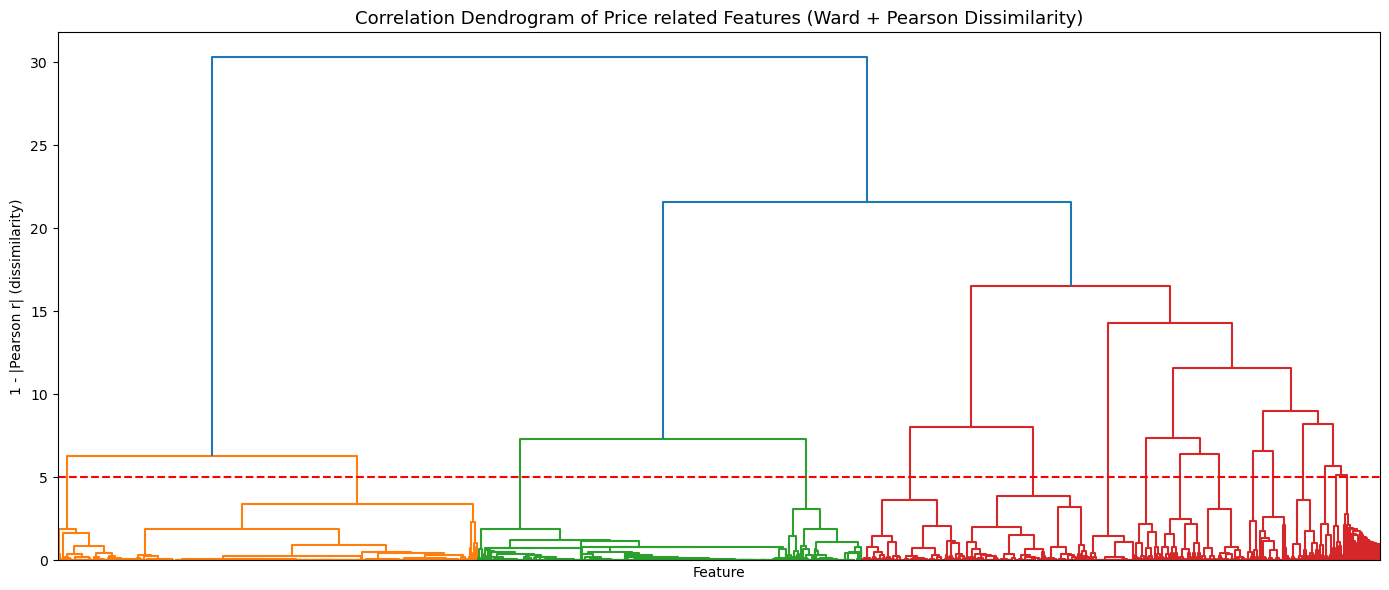

In [37]:
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, no_labels=True, ax=ax)
ax.set_title("Correlation Dendrogram of Price related Features (Ward + Pearson Dissimilarity)", fontsize=13)
ax.set_xlabel("Feature")
ax.set_ylabel("1 - |Pearson r| (dissimilarity)")
plt.axhline(y=5, color="red", linestyle="--", label="Dissimilarity Threshold (0.5)")
plt.tight_layout()
plt.show()

In [55]:
from scipy.cluster.hierarchy import fcluster

clusters_price = fcluster(Z, t=15, criterion="maxclust")

cluster_map_price = dict(zip(prices.columns, clusters_price))


cluster_df_price = pd.DataFrame({
    "feature": prices.columns,
    "cluster": clusters_price
})
cluster_df_price.head()

,feature,cluster
0,price_111d_sma,2
1,price_111d_sma_ratio,7
2,price_111d_sma_ratio_0sd_usd,2
3,price_111d_sma_ratio_0sd_usd_sats,7
4,price_111d_sma_ratio_1m_sma,11


In [52]:
cluster_df_price.value_counts("cluster")

cluster
2     1556
3     1411
6      567
5      480
1      365
4      342
15     217
10     202
7      200
9      186
12     143
13     128
8      124
11      64
14      60
Name: count, dtype: int64

In [ ]:
cluster_df_price.sort_values("cluster")

In [40]:
zoom_cols = cluster_df_price[cluster_df_price["cluster"] == 14]["feature"].tolist()
zoom_cols

['price_12d_ema_ratio_pct1',
 'price_12d_ema_ratio_pct2',
 'price_12d_ema_ratio_pct5',
 'price_13d_ema_ratio_pct1',
 'price_13d_ema_ratio_pct2',
 'price_13d_ema_ratio_pct5',
 'price_13d_sma_ratio_pct1',
 'price_13d_sma_ratio_pct2',
 'price_13d_sma_ratio_pct5',
 'price_1m_ema_ratio_1y_m3sd_usd_sats',
 'price_1m_ema_ratio_4y_m3sd_usd_sats',
 'price_1m_ema_ratio_m3sd_usd_sats',
 'price_1m_ema_ratio_pct1',
 'price_1m_ema_ratio_pct2',
 'price_1m_ema_ratio_pct5',
 'price_1m_sma_ratio_1y_m2_5sd_usd_sats',
 'price_1m_sma_ratio_4y_m3sd_usd_sats',
 'price_1m_sma_ratio_m3sd_usd_sats',
 'price_1m_sma_ratio_pct1',
 'price_1m_sma_ratio_pct2',
 'price_1m_sma_ratio_pct5',
 'price_1w_ema_ratio_pct1',
 'price_1w_ema_ratio_pct2',
 'price_1w_ema_ratio_pct5',
 'price_1w_sma_ratio_pct1',
 'price_1w_sma_ratio_pct2',
 'price_1w_sma_ratio_pct5',
 'price_21d_ema_ratio_pct1',
 'price_21d_ema_ratio_pct2',
 'price_21d_ema_ratio_pct5',
 'price_21d_sma_ratio_1y_m3sd_usd_sats',
 'price_21d_sma_ratio_pct1',
 'price_21

/var/folders/8t/x329s8055vdgtxtnhtz6vkzr0000gn/T/ipykernel_60908/2117890444.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


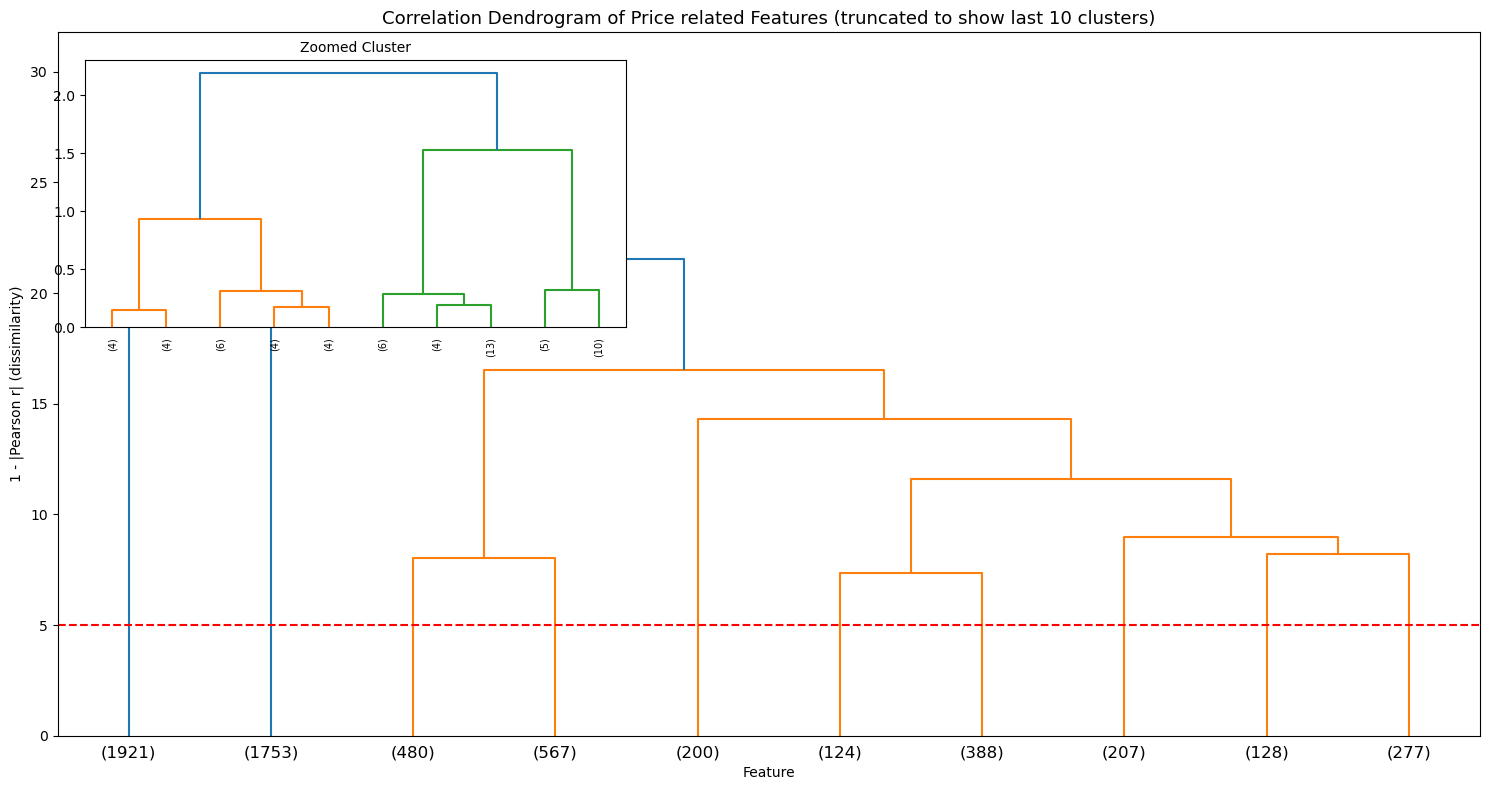

In [49]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(15, 8))
dendrogram(Z, truncate_mode='lastp', p=10,labels=prices.columns, ax=ax)
ax.set_title("Correlation Dendrogram of Price related Features (truncated to show last 10 clusters)", fontsize=13)
ax.set_xlabel("Feature")
ax.set_ylabel("1 - |Pearson r| (dissimilarity)")
plt.axhline(y=5, color="red", linestyle="--")

# -----------------------------
# 2. Inset dendrogram
# -----------------------------
zoom_corr = prices[zoom_cols].corr(method="pearson").abs()
zoom_dist = 1 - zoom_corr

Z_zoom = linkage(squareform(zoom_dist, checks=False), method="ward")

axins = inset_axes(
    ax,
    width="38%",
    height="38%",
    loc="upper left",
    borderpad=2
)

dendrogram(
    Z_zoom,
    truncate_mode='lastp', p=10,
    labels=zoom_cols,
    ax=axins,
    leaf_rotation=90,
    leaf_font_size=7
)

axins.set_title("Zoomed Cluster", fontsize=10)
axins.set_ylabel("")
axins.set_xlabel("")

plt.tight_layout()
plt.show()

In [56]:
ddata = dendrogram(

    Z,

    truncate_mode="lastp",

    p=10,

    no_plot=True

)

shown_nodes = ddata["leaves"]

shown_nodes

[12076, 12079, 12072, 12073, 12032, 12061, 12077, 12078, 12071, 12075]

In [57]:
n = len(prices.columns)

def get_cluster_members(node_id, Z, labels):
    """
    Given a dendrogram node ID, return original feature names inside it.
    """
    if node_id < n:
        return [labels[node_id]]
    
    row = int(node_id - n)
    left = int(Z[row, 0])
    right = int(Z[row, 1])
    
    return (
        get_cluster_members(left, Z, labels)
        + get_cluster_members(right, Z, labels)
    )

In [58]:
last10_clusters = []

for i, node in enumerate(shown_nodes, start=1):
    members = get_cluster_members(node, Z, list(prices.columns))
    
    last10_clusters.append({
        "display_cluster": i,
        "node_id": node,
        "n_features": len(members),
        "features": members
    })

last10_df = pd.DataFrame(last10_clusters)

last10_df

,display_cluster,node_id,n_features,features
0,1,12076,1921,"[price_5y_ago, price_2y_sma_ratio_1y_m1sd_usd,..."
1,2,12079,1753,"[price_2y_sma_ratio_2y_m2_5sd, price_2y_sma_ra..."
2,3,12072,480,"[price_21d_ema_ratio_1y_p2sd, price_12d_ema_ra..."
3,4,12073,567,"[price_55d_ema_ratio_pct5, price_55d_ema_ratio..."
4,5,12032,200,"[price_1w_sma_ratio, price_8d_sma_ratio, price..."
5,6,12061,124,"[price_55d_ema_ratio_1y_m1sd, price_55d_sma_ra..."
6,7,12077,388,"[price_1m_sma_ratio_2y_m2_5sd, price_34d_sma_r..."
7,8,12078,207,"[price_55d_ema_ratio_1w_sma, price_89d_ema_rat..."
8,9,12071,128,"[price_21d_sma_ratio_1y_zscore, price_1m_sma_r..."
9,10,12075,277,"[price_8d_sma_ratio_pct5, price_1w_sma_ratio_p..."


In [59]:
for row in last10_clusters:
    print(f"\nCluster {row['display_cluster']} | {row['n_features']} features")
    print(row["features"])


Cluster 1 | 1921 features
['price_5y_ago', 'price_2y_sma_ratio_1y_m1sd_usd', 'price_200w_ema_ratio_1y_m1sd_usd', 'price_4y_ema_ratio_1y_m1sd_usd', 'price_1y_ema_ratio_1y_m2sd_usd', 'price_2y_ema_ratio_1y_m1_5sd_usd', 'price_6y_ago', 'price_2y_sma_ratio_2y_m1sd_usd', 'price_200w_ema_ratio_2y_m1sd_usd', 'price_4y_ema_ratio_2y_m1sd_usd', 'price_2y_ago', 'price_200w_sma_ratio_1y_m1sd_usd', 'price_4y_sma_ratio_1y_m1sd_usd', 'price_89d_sma_ratio_2y_m3sd_usd', 'price_200w_sma_ratio_2y_m1sd_usd', 'price_4y_sma_ratio_2y_m1sd_usd', 'price_200d_sma_ratio_2y_m2sd_usd', 'price_144d_ema_ratio_2y_m3sd_usd', 'price_200d_ema_ratio_2y_m2_5sd_usd', 'price_1y_sma_ratio_2y_m1_5sd_usd', 'price_350d_sma_ratio_2y_m1_5sd_usd', 'price_1y_ema_ratio_2y_m2sd_usd', 'price_2y_ema_ratio_2y_m1_5sd_usd', 'price_111d_sma_ratio_1y_m2_5sd_usd', 'price_144d_sma_ratio_1y_m2sd_usd', 'price_89d_sma_ratio_1y_m3sd_usd', 'price_1y_sma_ratio_1y_m1_5sd_usd', 'price_350d_sma_ratio_1y_m1_5sd_usd', 'price_200d_sma_ratio_1y_m2sd_usd'

In [51]:
fig.savefig(ROOT / "docs" / "figures" / "price_dendrogram_new.png", dpi=300)